In [13]:
import os
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

os.getcwd()

'/home/korit/Tae_ws/Proj_Age_and_gender_estimation_based_on_facial_images/test'

📂 총 6개의 이미지 파일을 발견했습니다. 분석을 시작합니다...

[1/6] 📷 파일 분석 중: Moon_1.webp


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  4.78it/s]


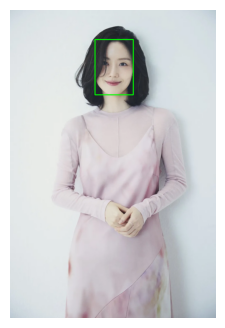

  [얼굴 #1]
  • 추정 나이 : 29 세
  • 추정 성별 : Woman (남성 0.0% / 여성 100.0%)


[2/6] 📷 파일 분석 중: Moon_2.webp


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  4.94it/s]


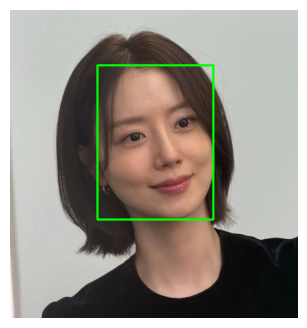

  [얼굴 #1]
  • 추정 나이 : 31 세
  • 추정 성별 : Woman (남성 0.0% / 여성 100.0%)


[3/6] 📷 파일 분석 중: Park_1_like_manhair.jpg


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  4.89it/s]


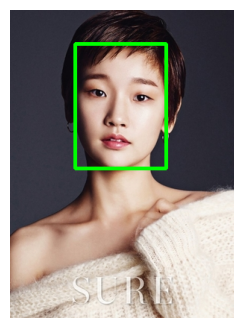

  [얼굴 #1]
  • 추정 나이 : 27 세
  • 추정 성별 : Woman (남성 16.1% / 여성 83.9%)


[4/6] 📷 파일 분석 중: Son_1.webp


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  4.85it/s]


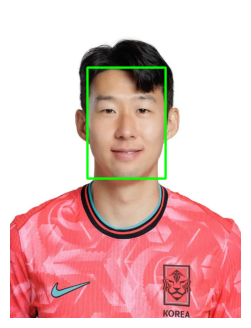

  [얼굴 #1]
  • 추정 나이 : 33 세
  • 추정 성별 : Man (남성 99.7% / 여성 0.3%)


[5/6] 📷 파일 분석 중: Son_2.jpg


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  4.80it/s]


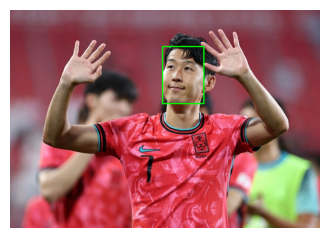

  [얼굴 #1]
  • 추정 나이 : 32 세
  • 추정 성별 : Man (남성 99.9% / 여성 0.1%)


[6/6] 📷 파일 분석 중: Yoon_1_like_manhair.jpg


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  4.11it/s]


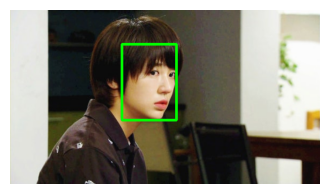

  [얼굴 #1]
  • 추정 나이 : 31 세
  • 추정 성별 : Man (남성 89.8% / 여성 10.2%)




In [14]:
# 1. images 폴더 경로 지정 (test.ipynb 위치 기준)
images_dir = "../images"
# 지원하는 이미지 확장자 목록
valid_extensions = ('.png', '.jpg', '.jpeg', '.webp', '.bmp')

if os.path.exists(images_dir):
    # 폴더 내 이미지 파일 목록 필터링
    image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(valid_extensions)])
    
    if not image_files:
        print(f"❌ '{images_dir}' 폴더에 분석할 이미지 파일이 없습니다.")
    else:
        print(f"📂 총 {len(image_files)}개의 이미지 파일을 발견했습니다. 분석을 시작합니다...\n")
        
        # 2. 이미지 파일별로 순회하며 분석 실행
        for i, file_name in enumerate(image_files, 1):
            img_path = os.path.join(images_dir, file_name)
            
            print(f"==================================================")
            print(f"[{i}/{len(image_files)}] 📷 파일 분석 중: {file_name}")
            print(f"==================================================")
            
            try:
                # DeepFace 나이 및 성별 분석 실행
                results = DeepFace.analyze(
                    img_path = img_path,
                    actions = ['age', 'gender'],
                    detector_backend = 'retinaface', # 탐지기 변경 시 'retinaface' 또는 'mediapipe'
                    enforce_detection = False
                )

                # 📸 [추가] 이미지 시각화 및 얼굴 영역 박스 그리기
                img = cv2.imread(img_path)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    for result in results:
                        region = result.get('region', {})
                        x, y, w, h = region.get('x', 0), region.get('y', 0), region.get('w', 0), region.get('h', 0)
                        if w > 0 and h > 0:
                            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
                    
                    plt.figure(figsize=(4, 4))
                    plt.imshow(img_rgb)
                    plt.axis('off')
                    plt.show()

                # 3. 결과 출력
                for idx, result in enumerate(results, 1):
                    age = result['age']
                    gender = result['dominant_gender']
                    gender_scores = result['gender']
                    print(f"  [얼굴 #{idx}]")
                    print(f"  • 추정 나이 : {age} 세")
                    print(f"  • 추정 성별 : {gender} (남성 {gender_scores['Man']:.1f}% / 여성 {gender_scores['Woman']:.1f}%)")
                print("\n")
            except Exception as e:
                print(f"  ❌ 분석 실패 ({file_name}): {e}\n")
                
else:
    print(f"❌ '{images_dir}' 경로를 찾을 수 없습니다.")